In [3]:
import quspin as qp
import numpy as np

#number of sites
l_x = 2
l_y = 2
N_sites = l_x * l_y #2x2 lattice, can change based on geometry
boundary = "closed" #PBC/closed = periodic closed boundary 1-2-3-4-1..., OBC/open = periodic open boundary /1-2-3-4/

#half-filled configuration
N_up = N_sites // 2 + N_sites % 2
N_down = N_sites // 2

#basis
basis = qp.basis.spinful_fermion_basis_1d(N_sites, Nf=(N_up, N_down))
#or
#basis_up = qp.basis.spinful_fermion_basis_1d(N_sites, Nf=N_up)
#basis_down = qp.basis.spinful_fermion_basis_1d(N_sites, Nf_N_down)
#basis = qp.basis.tensor_basis(basis_up, basis_down)

#hopping term
J = 1.0
#chemical potential - not used?
mu = 0.0
#U values
U_terms = [0.0, 2.0, 4.0, 8.0]

#hopping lists
hop_left = []
hop_right = []

#helper lambda for 2D coordinates
get_index = lambda x, y: x + y * l_x

for y in range(l_y):
    for x in range(l_x):
        current_site = get_index(x, y)

        #X hopping
        if (x+1 < l_x):
            next_x = get_index(x + 1, y)
            hop_right.append([-J, current_site, next_x])
            hop_left.append([+J, current_site, next_x])
        elif boundary == "closed" and l_x > 2: #periodic boundary so loop
            next_x = get_index(0,y)
            hop_right.append([-J, current_site, next_x])
            hop_left.append([+J, current_site, next_x])
        #Y hopping
        if (l_y > 1): #2 Dimensional Lattice
            if y + 1 < l_y:
                next_y = get_index(x, y +1)
                hop_right.append([-J, current_site, next_y])
                hop_left.append([+J, current_site, next_y])
            elif boundary == "closed" and l_y > 2:
                next_y = get_index(x,0)
                hop_right.append([-J, current_site, next_y])
                hop_left.append([+J, current_site, next_y])

#on-site potential list (not used?
pot = [[-mu, i] for i in range(N_sites)]

#generate variaties matrix
hamiltonian_collection = {}
no_checks = dict(check_pcon=False, check_symm=False, check_herm=False)

for U in U_terms:
    #interaction array for U value
    interact = [[U, i, i] for i in range(N_sites)]

    static_terms = [
        ['+-|', hop_left],   # spin-up hops left
        ['-+|', hop_right],  # spin-up hops right
        ['|+-', hop_left],   # spin-down hops left
        ['|-+', hop_right],  # spin-down hops right
        ['n|', pot],         # spin-up potential
        ['|n', pot],         # spin-down potential
        ['n|n', interact]    # on-site Coulomb repulsion
    ]       

    #build hamiltonian
    H = qp.operators.hamiltonian(static_terms, [], basis=basis, dtype=np.float64, **no_checks)

    #save with key -> could switch to list later
    geometry_string = f"{l_x}x{l_y}_{boundary}"
    key = f"Hubbard_{geometry_string}_U_{U:.2f}"
    hamiltonian_collection[key] = H


for name in hamiltonian_collection.keys():
    print(f" - {name}, {hamiltonian_collection[name]}")
 

 - Hubbard_2x2_closed_U_0.00, static mat: 
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 192 stored elements and shape (36, 36)>
  Coords	Values
  (0, 2)	1.0
  (0, 3)	-1.0
  (0, 12)	1.0
  (0, 18)	-1.0
  (1, 2)	1.0
  (1, 3)	1.0
  (1, 13)	1.0
  (1, 19)	-1.0
  (2, 0)	1.0
  (2, 1)	1.0
  (2, 4)	1.0
  (2, 5)	1.0
  (2, 14)	1.0
  (2, 20)	-1.0
  (3, 0)	-1.0
  (3, 1)	1.0
  (3, 4)	1.0
  (3, 5)	-1.0
  (3, 15)	1.0
  (3, 21)	-1.0
  (4, 2)	1.0
  (4, 3)	1.0
  (4, 16)	1.0
  (4, 22)	-1.0
  (5, 2)	1.0
  :	:
  (30, 33)	-1.0
  (31, 13)	1.0
  (31, 19)	-1.0
  (31, 32)	1.0
  (31, 33)	1.0
  (32, 14)	1.0
  (32, 20)	-1.0
  (32, 30)	1.0
  (32, 31)	1.0
  (32, 34)	1.0
  (32, 35)	1.0
  (33, 15)	1.0
  (33, 21)	-1.0
  (33, 30)	-1.0
  (33, 31)	1.0
  (33, 34)	1.0
  (33, 35)	-1.0
  (34, 16)	1.0
  (34, 22)	-1.0
  (34, 32)	1.0
  (34, 33)	1.0
  (35, 17)	1.0
  (35, 23)	-1.0
  (35, 32)	1.0
  (35, 33)	-1.0


dynamic:

 - Hubbard_2x2_closed_U_2.00, static mat: 
<Compressed Sparse Row sparse matrix of dtype 'floa

In [4]:
import quspin as qp
import numpy as np
import scipy as sp


def calculate_ground_state(sparse_matrix):
    '''
    Given a QuSpin sparse matrix, compute the ground state energy and eigenvector
    argument: sparse_matrix
    return: (ground_state_energy, ground_eigenvector)
    '''
    ground_eigenvalue, ground_eigenvector = sparse_matrix.eigsh(k=1, which="SA")
    ground_state_energy = np.abs(ground_eigenvalue[0])
    return (ground_state_energy, ground_eigenvector)

def calculate_charge_correlation_matrix(psi, N_site):
    '''Given a Ground State Eigenvector (psi) and number of sites (N_sites), compute the spin-spin correlation matrix
    Arguments: psi, N_sites
    Return: charge_correlation_matrix (N_sites x N_sites matrix)
    '''
    charge_correlation_matrix = np.zeros((N_sites, N_sites))
    no_checks = dict(check_pcon = False, check_symm = False, check_herm = False)
    #make psi a 1D column if not
    if psi.ndim > 1:
        psi0 = psi.ravel()
        
    N_up = N_sites // 2 + N_sites % 2
    N_down = N_sites // 2
    basis = qp.basis.spinful_fermion_basis_1d(N_sites, Nf=(N_up, N_down))

    #calcuate local density expectation value <n_j> for all sites
    n_averages = np.zeros(N_sites)
    for j in range(N_sites):
        n_op = qp.operators.hamiltonian([
            ['n|', [[1.0, j]]],
            ['|n', [[1.0, j]]]],
                           [],
                           basis = basis,
                           dtype=np.float64,
                           **no_checks)
        n_averages[j] = np.real(n_op.expt_value(psi0))

    #compute the <n_j, n_k> matrix elements
    for j in range(N_sites):
        for k in range(N_sites):
            static_list = [
                ['n|n', [[1.0, j, k]]],  # n_up_j   * n_up_k
                ['|nn', [[1.0, j, k]]],  # n_down_j * n_down_k
                ['n|n', [[1.0, j, k]]],  # n_up_j   * n_down_k
                ['n|n', [[1.0, k, j]]]   # n_up_k   * n_down_j
            ]
            nj_nk_op = qp.operators.hamiltonian(static_list, [], basis=basis, dtype = np.float64, **no_checks)
            expt_nj_nk = np.real(nj_nk_op.expt_value(psi0))

            #subtract the disconneced background <n_j><n_k>
            charge_correlation_matrix[j, k] = expt_nj_nk - (n_averages[j] * n_averages[k]) 

    return charge_correlation_matrix
            
def calculate_spin_correlation_matrix(psi, N_sites):
    '''
    Given a Ground State Eigenvector (psi) and number of sites (N_sites), compute the spin-spin correlation matrix
    arguments: psi, N_sites
    return: spin_correlation_matrix (N_sites x N_sites matrix)
    '''
    spin_correlation_matrix = np.zeros((N_sites, N_sites))
    no_checks = dict(check_pcon = False, check_symm = False, check_herm = False)

    N_up = N_sites // 2 + N_sites % 2
    N_down = N_sites // 2
    basis = qp.basis.spinful_fermion_basis_1d(N_sites, Nf=(N_up, N_down))

    #make psi a 1D column if not
    if psi.ndim > 1:
        psi0 = psi.ravel()

    for j in range(N_sites):
        for k in range(N_sites):
            #Sz_j x Sz_k matrix
            static_list = [
                ['n|n', [[0.25, j, k]]],    #0.25 * n-up-j * n-up-k
                ['|nn', [[0.25, j, k]]],    #0.25 * n-down-j * n-down-k
                ['n|n', [[-0.25, j, k]]],   #-0.25 * n-up-j * n-down-k
                ['n|n', [[-0.25, k, j]]]   #-0.25 * n-up-k * n-down-k
            ]
            #static lists for individual n operators

            #build operator
            O_jk = qp.operators.hamiltonian(static_list, [], basis=basis, dtype=np.float64, **no_checks)

            #calcluate expectation value
            val = O_jk.expt_value(psi0)

            #save to matrix
            spin_correlation_matrix[j, k] = np.real(val)

    return spin_correlation_matrix
    
def calculate_structure_factor(spin_correlation_matrix, l_x, l_y = 1):
    '''
    Given a spin-spin correlation matrix and dimensions of the lattice (square),
    calculate the structure factor
    Arguments: Spin-Spin Correlation Matrix, X length, Y length
    Returns: Qx, Qy, S(q) -> Structure Factor
    '''
    #Check N_sites
    N_sites = l_x * l_y
    if spin_correlation_matrix.shape != (N_sites, N_sites):
        raise ValueError("Matrix Dimensions do not match specified grid")

    #map (0 to N-1) indices to physical (x,y) coordinates (for 2D shapes)
    coordinates = []
    for y in range(l_y):
        for x in range(l_x):
            coordinates.append(np.array([x,y]))

    #define allowed momentum grid 
    qx_modes = np.linspace(0,2*np.pi, l_x, endpoint=False)
    qy_modes = np.linspace(0,2*np.pi, l_y, endpoint=False)

    #S(q) grid
    S_q_grid = np.zeros((l_y, l_x))

    #2D Discrete Fourier Transform
    for ky_idx, qy in enumerate(qy_modes):
        for kx_idx, qx in enumerate(qx_modes):
            q_vector = np.array([qx, qy])

            sq_val = 0.0 + 0.0j
            for j in range(N_sites):
                for k in range(N_sites):
                    r_j = coordinates[j]
                    r_k = coordinates[k]

                    #dot product
                    phase = np.exp(-1j * np.dot(q_vector, r_j - r_k))
                    sq_val += phase * spin_correlation_matrix[j,k]

            S_q_grid[ky_idx, kx_idx] = np.real(sq_val)/N_sites

    return qx_modes, qy_modes, S_q_grid
        

g1val, g1vec = calculate_ground_state(hamiltonian_collection["Hubbard_2x2_closed_U_4.00"])
print("Ground State Value: \n", g1val)
#print("Ground State Vector: \n", g1vec)
spin_correlation_matrix = calculate_spin_correlation_matrix(g1vec, 4)
charge_correlation_matrix = calculate_charge_correlation_matrix(g1vec, 4)
print("spin_correlation_matrix: \n", spin_correlation_matrix)
print("charge_correlation_matrix: \n", charge_correlation_matrix)



Ground State Value: 
 2.1027484834620735
spin_correlation_matrix: 
 [[ 0.10704216 -0.06858601 -0.06858601  0.03012986]
 [-0.06858601  0.10704216  0.03012986 -0.06858601]
 [-0.06858601  0.03012986  0.10704216 -0.06858601]
 [ 0.03012986 -0.06858601 -0.06858601  0.10704216]]
charge_correlation_matrix: 
 [[-0.28450597  0.20773369  0.20773369 -0.13096141]
 [ 0.20773369 -0.28450597 -0.13096141  0.20773369]
 [ 0.20773369 -0.13096141 -0.28450597  0.20773369]
 [-0.13096141  0.20773369  0.20773369 -0.28450597]]


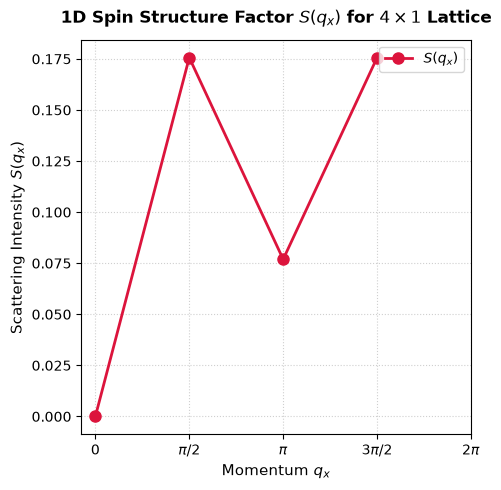

In [5]:
import matplotlib.pyplot as plt

Qx, Qy, S_q = calculate_structure_factor(spin_correlation_matrix,4,1)
S_q_0 = S_q[0, :]

plt.figure(figsize=(5,5))

extent = [Qx[0], 2*np.pi, Qy[0], 2*np.pi] #1
#im = plt.imshow(S_q, extent=extent, origin= 'lower', cmap = 'viridis', interpolation = 'nearest') #1
plt.plot(Qx, S_q_0, marker='o', linestyle='-', color='crimson', linewidth=2, markersize=8, label='$S(q_x)$') #2 start

tick_values = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi] #1&2
tick_labels = ['$0$', '$\pi/2$', '$\pi$', '$3\pi/2$', '$2\pi$'] #1&2

plt.xticks(tick_values, tick_labels) #1&2
#plt.yticks(tick_values, tick_labels)

#plt.title('Spin Structure Factor $S(\mathbf{q})$ in Momentum Space', fontsize=12, fontweight='bold', pad=12)
#plt.xlabel('Momentum $q_x$', fontsize=11)
#plt.ylabel('Momentum $q_y$', fontsize=11)

# Add a colorbar to show the intensity scale
#cbar = plt.colorbar(im)
#cbar.set_label('Scattering Intensity $S(q)$', fontsize=10)

#plt.tight_layout()
#plt.show()

plt.title('1D Spin Structure Factor $S(q_x)$ for $4 \\times 1$ Lattice', fontsize=12, fontweight='bold', pad=12) #2
plt.xlabel('Momentum $q_x$', fontsize=11) #2
plt.ylabel('Scattering Intensity $S(q_x)$', fontsize=11) #2

plt.grid(True, linestyle=':', alpha=0.6) #2
plt.legend(loc='best') #2

plt.tight_layout() #2
plt.show()#2


In [ ]:
import matplotlib.pyplot as plt

for name in hamiltonian_collection.keys(): 
    # 1. Grab the sparse matrix from your QuSpin Hamiltonian object
    matrix_sparse = hamiltonian_collection[name].static
    
    # 2. Create the spy plot
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.spy(matrix_sparse, markersize=5, color='darkblue')
    
    # 3. Add styling and labels
    ax.set_title("Hubbard Hamiltonian Sparsity Pattern", fontsize=12, fontweight='bold', pad=15)
    ax.set_xlabel("Basis State Index (Columns)", fontsize=10)
    ax.set_ylabel("Basis State Index (Rows)", fontsize=10)
    ax.grid(True, which='both', color='gray', linestyle=':', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()


In [7]:
import numpy as np
import quspin.operators as qp
from quspin.basis import spin_basis_1d

# 1. System Parameters
N_sites = 8  # Total qubits (0 to 7)
no_checks = dict(check_pcon=False, check_symm=False, check_herm=False)

# 2. Build the Spin-1/2 Qubit Basis
# (We don't restrict magnetization here because the raw PL dataset includes all blocks)
basis = spin_basis_1d(N_sites, S="1/2")

# 3. Translate your PennyLane equation into QuSpin operator strings
# Format: [ 'Pauli_String', [[coefficient, site0, site1, ...]] ]
static_list = [
    # --- Spin-Up Sector Hopping/XY terms ---
    ['yy', [[0.5, 0, 1]]], ['xx', [[0.5, 0, 1]]],
    ['yy', [[0.5, 2, 1]]], ['xx', [[0.5, 2, 1]]],
    ['yy', [[0.5, 3, 2]]], ['xx', [[0.5, 3, 2]]],
    
    # --- Spin-Up Jordan-Wigner Boundary Hopping ---
    ['xzzx', [[0.5, 0, 1, 2, 3]]],
    ['yzzy', [[0.5, 0, 1, 2, 3]]],
    
    # --- Spin-Down Sector Hopping/XY terms ---
    ['yy', [[0.5, 5, 4]]], ['xx', [[0.5, 5, 4]]],
    ['yy', [[0.5, 6, 5]]], ['xx', [[0.5, 6, 5]]],
    ['yy', [[0.5, 7, 6]]], ['xx', [[0.5, 7, 6]]],
    
    # --- Spin-Down Jordan-Wigner Boundary Hopping ---
    ['xzzx', [[0.5, 4, 5, 6, 7]]],
    ['yzzy', [[0.5, 4, 5, 6, 7]]],
    
    # --- Density-Density Interacting terms (Coulomb U) ---
    ['zz', [[0.017676767676767676, 0, 4]]],
    ['zz', [[0.017676767676767676, 1, 5]]],
    ['zz', [[0.017676767676767676, 2, 6]]],
    ['zz', [[0.017676767676767676, 3, 7]]]
]
# 4. Construct the Hamiltonian
H = qp.hamiltonian(static_list, [], basis=basis, dtype=np.complex128, **no_checks)

# 5. Solve for the Ground State
E, V = H.eigsh(k=1, which="SA")  # SA = Smallest Algebraic (Ground state)
E0 = E[0]
psi0 = V[:, 0]

print(f"Verified Ground State Energy E0: {E0:.6f}")

Verified Ground State Energy E0: -4.018180


In [31]:
(0.5+0j) * (Y(0) @ Y(1)) + 
(0.5+0j) * (X(0) @ X(1)) + 
    '+-|', [[0.5, j, k], [0.5, k, j]]
(0.5+0j) * (Y(2) @ Y(1)) + 
(0.5+0j) * (X(2) @ X(1)) + 
    '+-|', [[0.5, j, k], [0.5, k, j]]
(0.5+0j) * (Y(3) @ Y(2)) + 
(0.5+0j) * (X(3) @ X(2)) + 
    '+-|', [0.5, j, k]
(0.5+0j) * (X(0) @ Z(1) @ Z(2) @ X(3)) + 
(0.5+0j) * (Y(0) @ Z(1) @ Z(2) @ Y(3)) + 
    '+-|', [[-0.5, 0, 3], [-0.5, 3, 0]]
(0.5+0j) * (Y(5) @ Y(4)) + 
(0.5+0j) * (X(5) @ X(4)) + 
    '|+-', [[0.5, j -4 , k -4], [0.5, k - 4, j - 4]]
(0.5+0j) * (Y(6) @ Y(5)) + 
(0.5+0j) * (X(6) @ X(5)) + 
    '|+-', [[0.5, j -4 , k -4], [0.5, k - 4, j - 4]]
(0.5+0j) * (Y(7) @ Y(6)) + 
(0.5+0j) * (X(7) @ X(6)) + 
    '|+-', [[0.5, j -4 , k -4], [0.5, k - 4, j - 4]]
(0.5+0j) * (X(4) @ Z(5) @ Z(6) @ X(7)) + 
(0.5+0j) * (Y(4) @ Z(5) @ Z(6) @ Y(7)) + 
    ['|+-', [[-0.5, 0, 3], [-0.5, 3, 0]]]
(0.017676767676767676+0j) * (Z(0) @ Z(4)) + 
(0.017676767676767676+0j) * (Z(1) @ Z(5)) + 
(0.017676767676767676+0j) * (Z(2) @ Z(6)) + 
(0.017676767676767676+0j) * (Z(3) @ Z(7))                 

Exact Fermionic Ground State Energy: -4.476721759838
